In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

def show_image(image, title='Image'):
    # Display an OpenCV image inline in the notebook.
    # OpenCV uses BGR channel order, matplotlib expects RGB.
    plt.figure(figsize=(8, 5))
    if image.ndim == 3:
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(image, cmap='gray', vmin=0, vmax=255)
    plt.title(title)
    plt.axis('off')
    plt.show()

In [2]:
############################### 3.1 Exercise #####################################

############################ 3.1.1 and 3.1.2 ####################################

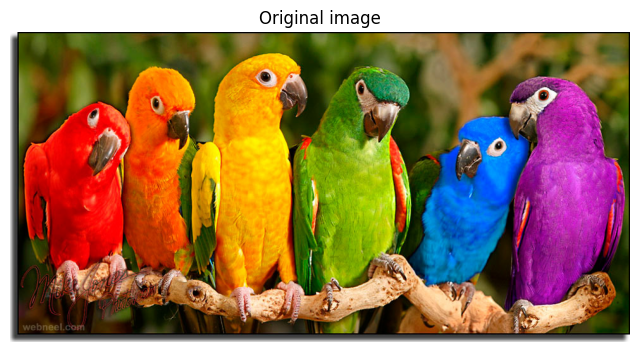

[[[255 255 255]
  [255 255 255]
  [254 254 254]
  ...
  [  0   4   1]
  [ 20   0   1]
  [  5   0   2]]

 [[255 255 255]
  [254 254 254]
  [253 253 253]
  ...
  [  0  12   6]
  [ 11   0   0]
  [  3   2   4]]

 [[254 254 254]
  [252 252 252]
  [250 250 250]
  ...
  [ 31  83  76]
  [ 13  12  14]
  [  0   1   1]]

 ...

 [[241 241 241]
  [233 233 233]
  [220 220 220]
  ...
  [251 251 251]
  [255 255 255]
  [252 252 252]]

 [[244 244 244]
  [239 239 239]
  [231 231 231]
  ...
  [250 250 250]
  [252 252 252]
  [254 254 254]]

 [[249 249 249]
  [245 245 245]
  [239 239 239]
  ...
  [253 253 253]
  [255 255 255]
  [255 255 255]]]
(490, 980, 3)


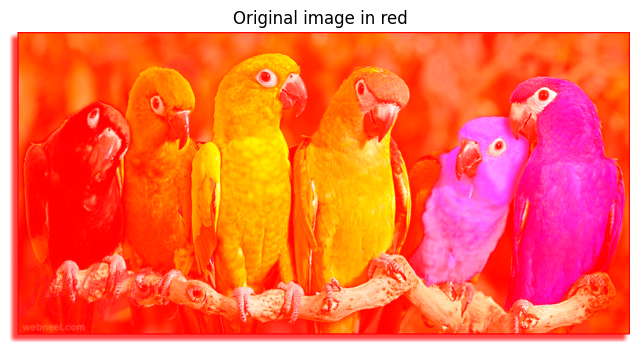

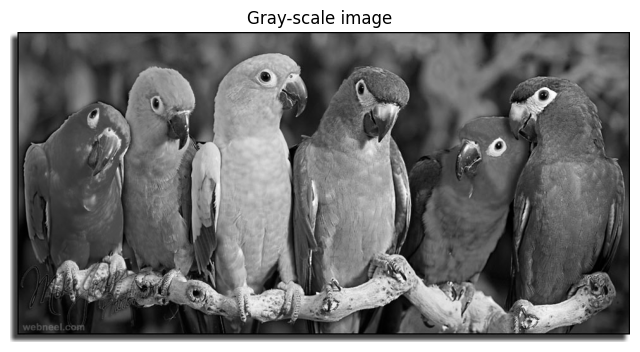

[[255 255 254 ...   2   1   1]
 [255 254 253 ...   7   0   3]
 [254 252 250 ...  75  13   1]
 ...
 [241 233 220 ... 251 255 252]
 [244 239 231 ... 250 252 254]
 [249 245 239 ... 253 255 255]]
(490, 980)


In [3]:
#Reading RGB image
img1 = cv2.imread('parrots.jpg')

show_image(img1, 'Original image')
print(img1)
print(img1.shape)

img1_red=img1.copy()
img1_red[:,:,2]=255
show_image(img1_red, 'Original image in red')


#Reading grey-scale image
img2 = cv2.imread('parrots.jpg',0)
show_image(img2, 'Gray-scale image')
print(img2)
print(img2.shape)

490 980


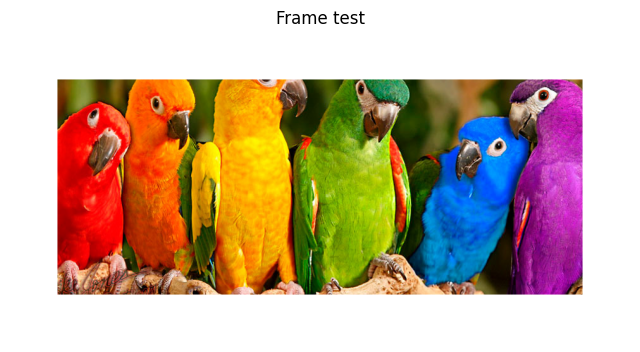

True

In [4]:
############################ 3.1.3 ####################################

cv2.imwrite('parrots_gray_test.jpg',img2)


############################ 3.1.4 ####################################

#img1 = cv2.imread('parrots.jpg')

height=img1.shape[0]
width=img1.shape[1]
print(height,width)

test=img1.copy()

#Making frame
# Set a 75-pixel wide border on every side to white (255 in all BGR channels)
test[:75, :] = 255       # top
test[-75:, :] = 255      # bottom
test[:, :75] = 255       # left
test[:, -75:] = 255      # right

show_image(test, 'Frame test')
cv2.imwrite('parrots_frame_test.jpg',test)

In [ ]:
############################ 3.1.5 ####################################
# Random noise matrix with the same shape as the gray-scale image, values in [0, 50]
noise=np.random.randint(0, 51, (height, width), dtype=np.uint8)
print(noise)

cv2.imwrite('noise.jpg',noise)
noise=cv2.imread('noise.jpg',0)
show_image(noise, 'Noise')


############################ 3.1.6 ####################################
# Add the noise to the gray-scale image
# cv2.add saturates at 255 instead of wrapping around like plain numpy addition
noiseimg=cv2.add(img2, noise)

show_image(noiseimg, 'Image noisy')
cv2.imwrite('parrots_noisy_test.jpg', noiseimg)

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# show_image is already defined in the first cell (handles both colour and gray images)

############################ 3.2.1 ####################################
def mean_filter(image, window=3):
    # Slide a window x window kernel over the image and replace each pixel
    # with the mean of its neighbourhood. Border pixels (where the window
    # would fall outside the image) are left unchanged.
    img = image.copy()
    height, width = image.shape
    pad = window // 2
    for i in range(pad, height - pad):
        for j in range(pad, width - pad):
            neighbourhood = image[i-pad:i+pad+1, j-pad:j+pad+1]
            # np.mean computes in float, so the uint8 sum cannot overflow
            img[i, j] = np.mean(neighbourhood)
    return img

############################ 3.2.2 ####################################
def median_filter(image, window=3):
    # Same sliding window, but each pixel becomes the median of its
    # neighbourhood - nonlinear, so it removes salt-and-pepper noise
    # without smearing edges the way the mean filter does.
    img_prime = image.copy()
    height, width = image.shape
    pad = window // 2
    for i in range(pad, height - pad):
        for j in range(pad, width - pad):
            neighbourhood = image[i-pad:i+pad+1, j-pad:j+pad+1]
            img_prime[i, j] = np.median(neighbourhood)
    return img_prime

# Load images
img1 = cv2.imread('parrots.jpg', 0)
img2 = cv2.imread('parrots_noisy_test.jpg', 0)

# Show the original noisy image
show_image(img1, 'Gray-scale Image')
show_image(img2, 'Noisy Image')

# Apply filters and show results
mean_filtered = mean_filter(img2)
show_image(mean_filtered, 'Mean Filtered Image')

median_filtered = median_filter(img2)
show_image(median_filtered, 'Median Filtered Image')

In [ ]:
############################ 3.2.3 ####################################
window=3

# Apply the mean filter
ksize = (window, window)  # Size of the filter kernel
opencv_mean_image = cv2.blur(img2, ksize)


# Apply the median filter
ksize = window  # Size of the filter kernel (window size)
opencv_median_image = cv2.medianBlur(img2, ksize)

show_image(opencv_mean_image, 'OpenCV filtered image (mean)')
show_image(opencv_median_image, 'OpenCV filtered image (median)')

In [ ]:
############################ 3.2.4 ####################################
# Try different kernel (window) sizes and compare.
# Small windows (3) remove less noise but keep detail; large windows (7, 9)
# remove more noise but blur edges and fine detail. For this noise level,
# 3x3 or 5x5 is about the sweet spot - especially for the median filter.

for window in [3, 5, 7, 9]:
    mean_result = cv2.blur(img2, (window, window))
    median_result = cv2.medianBlur(img2, window)
    show_image(mean_result, f'Mean filter {window}x{window}')
    show_image(median_result, f'Median filter {window}x{window}')

In [ ]:
import cv2

#captures all the frames
video = cv2.VideoCapture('tom_and_jerry.mp4')

#Check if video opened successfully
if (video.isOpened()== False): 
    print("Error opening video stream or file")

#fram/sec in video and duration of it
fps = video.get(cv2.CAP_PROP_FPS)
print('frames per second =',fps)

#total number of frames
length = int(video.get(cv2.CAP_PROP_FRAME_COUNT))
print('total number of frames =',length)
print('duration of the video (in sec) =',length/fps)

video.set(cv2.CAP_PROP_POS_FRAMES, 1002)
ret, frame = video.read()
show_image(frame, 'Frame 1002')

In [ ]:
############################ 4.1.2 ####################################

# Canny thresholds - 4.1.3: change these and re-run to see the effect.
# Lower both (e.g. 30/100)  -> more edges, including noise and texture.
# Raise both (e.g. 200/400) -> only the strongest edges survive.
lower_threshold = 100
upper_threshold = 200

# Re-open the video so playback starts from the first frame
# (the previous cell left the position at frame 1003)
video = cv2.VideoCapture('tom_and_jerry.mp4')

# Read until video is completed
# NOTE: this plays in desktop windows (matplotlib can't do real-time video)
while(video.isOpened()):
  # Capture frame-by-frame
  ret, frame = video.read()
  if ret == True:
    # Canny works on intensity gradients, so convert to gray-scale first
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, lower_threshold, upper_threshold)

    # Display the original and the edge video side by side
    cv2.imshow('Original', frame)
    cv2.imshow('Canny edges', edges)

    if cv2.waitKey(1) == 27:         # wait for ESC key to exit, 27 is the escape key number
      break
 
  # Break the loop
  else: 
    break
# When everything done, release the video capture object
video.release()
# Closes all the frames
cv2.destroyAllWindows()


In [ ]:
############################ 4.1.3 ####################################
# Effect of the Canny thresholds, shown inline on a single frame.
# Pixels with gradient > upper are strong edges; pixels between lower and
# upper are kept only if connected to a strong edge; below lower is discarded.

video = cv2.VideoCapture('tom_and_jerry.mp4')
video.set(cv2.CAP_PROP_POS_FRAMES, 1002)
ret, frame = video.read()
video.release()

gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

show_image(frame, 'Original frame')
for lower, upper in [(30, 100), (100, 200), (200, 400)]:
    edges = cv2.Canny(gray, lower, upper)
    show_image(edges, f'Canny edges (lower={lower}, upper={upper})')

In [ ]:
############################### 5.1 Exercise #####################################

############################ 5.1.2 and 5.1.3 ####################################


# import tensorflow_datasets as tfds
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
import datetime
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
# import cv2



## Loading MNIST dataset
(train_ds, train_labels), (test_ds, test_labels) = tf.keras.datasets.mnist.load_data()


## MNIST dataset images are 28*28, and they are between 0-255. 
#Preprocessing part 1 


## Transforming labels
train_labels = to_categorical(train_labels, num_classes=10)
test_labels = to_categorical(test_labels, num_classes=10)


## Preprocessing part 2



## Loading VGG16 model
base_model = VGG16(weights="imagenet", include_top=False, input_shape=(32, 32, 3))
base_model.trainable = False ## Not trainable weights


############################ 5.1.4 ####################################

base_model.summary()


In [ ]:
############################ 5.1.5 ####################################

from tensorflow.keras import layers, models

#### TO DO PART ####
# add the requested layers

model = models.Sequential([
...
])

model.compile(
...
)

es = EarlyStopping(monitor='val_accuracy', mode='max', patience=5, restore_best_weights=True)

start = datetime.datetime.now()

history = model.fit(train_ds, train_labels, epochs=5, validation_split=0.2, batch_size=32, callbacks=[es])

score = model.evaluate(test_ds, test_labels, batch_size=32)
x_valid_output_images = model.predict(test_ds)

# Get training and test loss histories
training_loss = history.history['loss']
test_loss = history.history['val_loss']

# Create count of the number of epochs
epoch_count = range(1, len(training_loss) + 1)


############################ 5.1.6 ####################################

# Visualize loss history
plt.plot(epoch_count, history.history['loss'], 'r--')
plt.plot(epoch_count, history.history['val_loss'], 'b-')
plt.legend(['Training Loss', 'Test Loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

end = datetime.datetime.now()
elapsed = end - start
print('Training time:', str(elapsed))
print('Test score:', score[0])
print('Test accuracy:', score[1])


In [ ]:
############################ 5.1.7 ####################################


## Loading MNIST dataset
(train_ds, train_labels), (test_ds, test_labels) = tf.keras.datasets.mnist.load_data()

## Displaying an image
image_index = 10
plt.imshow(train_ds[image_index], cmap='gray')
plt.axis('off')
plt.show()

## TO DO PART ###
# Preprocessing  images
....

predicted_label = model.predict(input_image)
predicted_class = ....

actual_class = ....

print("Actual class:", actual_class)
print("Predicted class:", predicted_class)